# Comparative Analysis: ANN vs CNN on CIFAR-10

**Objective:** Train an Artificial Neural Network (ANN / fully-connected network) and a
Convolutional Neural Network (CNN) on the same dataset CIFAR-10  under comparable
conditions, then compare their accuracy, loss, training time, and parameter efficiency to
understand why CNNs are the standard architecture for image classification.

**Dataset:** CIFAR-10 — 60,000 32x32 color images in 10 classes (50,000 train / 10,000 test),
loaded via `tf.keras.datasets.cifar10`.

**Framework:** TensorFlow / Keras.

## 1. Setup and Imports

In [1]:
import warnings
warnings.filterwarnings('ignore')

import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

# Enable inline plotting when running inside a Jupyter/IPython kernel;
# fall back gracefully to a non-interactive backend otherwise.
try:
    get_ipython().run_line_magic('matplotlib', 'inline')
except NameError:
    import matplotlib
    matplotlib.use('Agg')

# Reproducibility
np.random.seed(42)
tf.random.set_seed(42)

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

print("TensorFlow version:", tf.__version__)
print("GPU available:", len(tf.config.list_physical_devices('GPU')) > 0)

TensorFlow version: 2.21.0
GPU available: False


## 2. Load and Explore the CIFAR-10 Dataset

CIFAR-10 consists of 60,000 32x32 color images across 10 mutually exclusive classes. The
dataset ships with Keras, so no manual download is required.

In [2]:
CLASS_NAMES = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

(x_train_raw, y_train_raw), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()
y_train_raw = y_train_raw.flatten()
y_test = y_test.flatten()

print(f"Training images : {x_train_raw.shape}")
print(f"Test images      : {x_test.shape}")
print(f"Image shape      : {x_train_raw.shape[1:]}  |  dtype: {x_train_raw.dtype}")
print(f"Pixel range      : [{x_train_raw.min()}, {x_train_raw.max()}]")
print(f"Classes ({len(CLASS_NAMES)})     : {CLASS_NAMES}")

Training images : (50000, 32, 32, 3)
Test images      : (10000, 32, 32, 3)
Image shape      : (32, 32, 3)  |  dtype: uint8
Pixel range      : [0, 255]
Classes (10)     : ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


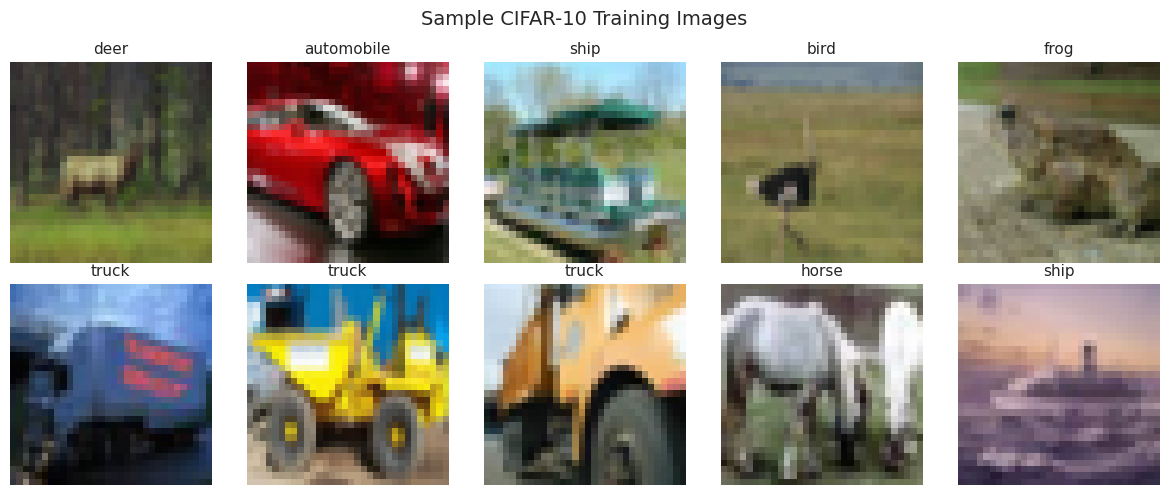

In [3]:
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
rng = np.random.default_rng(42)
sample_idx = rng.choice(len(x_train_raw), 10, replace=False)
for ax, idx in zip(axes.flat, sample_idx):
    ax.imshow(x_train_raw[idx])
    ax.set_title(CLASS_NAMES[y_train_raw[idx]], fontsize=11)
    ax.axis('off')
plt.suptitle('Sample CIFAR-10 Training Images', fontsize=14)
plt.tight_layout()
plt.show()

## 3. Data Preprocessing

- Pixel values are rescaled from `[0, 255]` to `[0, 1]` to stabilize gradient-based training.
- A stratified 10% validation split is carved out of the training set so the test set stays
  completely untouched until final evaluation — this keeps the comparison honest.

In [4]:
x_train_full = x_train_raw.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

x_train, x_val, y_train, y_val = train_test_split(
    x_train_full, y_train_raw, test_size=0.1, stratify=y_train_raw, random_state=42
)

print(f"Train: {x_train.shape[0]:,} images")
print(f"Val:   {x_val.shape[0]:,} images")
print(f"Test:  {x_test.shape[0]:,} images")

EPOCHS = int(os.environ.get('NB_EPOCHS', 15))
BATCH_SIZE = 128
print(f"\nEPOCHS = {EPOCHS}, BATCH_SIZE = {BATCH_SIZE}")

Train: 45,000 images
Val:   5,000 images
Test:  10,000 images

EPOCHS = 15, BATCH_SIZE = 128


## 4. Model 1: Artificial Neural Network (ANN)

The ANN is a fully-connected (dense) network. Dense layers expect 1-D input, so the first
step is `Flatten()`, which unrolls the 32x32x3 image into a 3,072-length vector — **this
discards every spatial relationship between neighboring pixels**, which will matter a lot
for the comparison later.

In [5]:
ann_model = keras.Sequential([
    layers.Input(shape=(32, 32, 3)),
    layers.Flatten(),
    layers.Dense(512, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
], name='ANN')

ann_model.compile(optimizer='adam',
                   loss='sparse_categorical_crossentropy',
                   metrics=['accuracy'])
ann_model.summary()

Model: "ANN"
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 3072)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     1,573,376 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───

### Training the ANN

In [6]:
t0 = time.time()
ann_history = ann_model.fit(
    x_train, y_train,
    validation_data=(x_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    verbose=2
)
ann_train_time = time.time() - t0
print(f"\nANN training time: {ann_train_time:.1f} seconds")

Epoch 1/15
352/352 - 11s - 31ms/step - accuracy: 0.2566 - loss: 2.0147 - val_accuracy: 0.3196 - val_loss: 1.8437
Epoch 2/15
352/352 - 9s - 27ms/step - accuracy: 0.3162 - loss: 1.8741 - val_accuracy: 0.3548 - val_loss: 1.7757
Epoch 3/15
352/352 - 11s - 31ms/step - accuracy: 0.3318 - loss: 1.8307 - val_accuracy: 0.3660 - val_loss: 1.7521
Epoch 4/15
352/352 - 11s - 31ms/step - accuracy: 0.3471 - loss: 1.7905 - val_accuracy: 0.3932 - val_loss: 1.7091
Epoch 5/15
352/352 - 10s - 29ms/step - accuracy: 0.3584 - loss: 1.7618 - val_accuracy: 0.3940 - val_loss: 1.6983
Epoch 6/15
352/352 - 10s - 28ms/step - accuracy: 0.3689 - loss: 1.7459 - val_accuracy: 0.3996 - val_loss: 1.7031
Epoch 7/15
352/352 - 10s - 29ms/step - accuracy: 0.3777 - loss: 1.7174 - val_accuracy: 0.4210 - val_loss: 1.6471
Epoch 8/15
352/352 - 11s - 31ms/step - accuracy: 0.3830 - loss: 1.7059 - val_accuracy: 0.4120 - val_loss: 1.6696
Epoch 9/15
352/352 - 12s - 33ms/step - accuracy: 0.3875 - loss: 1.6902 - val_accuracy: 0.4042 - v

### Evaluating the ANN

In [7]:
ann_test_loss, ann_test_acc = ann_model.evaluate(x_test, y_test, verbose=0)
print(f"ANN Test Accuracy: {ann_test_acc:.4f}")
print(f"ANN Test Loss:     {ann_test_loss:.4f}")

ann_pred_probs = ann_model.predict(x_test, verbose=0)
ann_preds = np.argmax(ann_pred_probs, axis=1)

ANN Test Accuracy: 0.4328
ANN Test Loss:     1.5899


## 5. Model 2: Convolutional Neural Network (CNN)

The CNN keeps the image's 2-D spatial structure intact. Convolutional filters are learned
and **shared across every location** in the image, and max-pooling progressively
down-samples the spatial dimensions, building up translation-tolerant features.

In [8]:
cnn_model = keras.Sequential([
    layers.Input(shape=(32, 32, 3)),
    layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax')
], name='CNN')

cnn_model.compile(optimizer='adam',
                   loss='sparse_categorical_crossentropy',
                   metrics=['accuracy'])
cnn_model.summary()

Model: "CNN"
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───

### Training the CNN

In [9]:
t0 = time.time()
cnn_history = cnn_model.fit(
    x_train, y_train,
    validation_data=(x_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    verbose=2
)
cnn_train_time = time.time() - t0
print(f"\nCNN training time: {cnn_train_time:.1f} seconds")

Epoch 1/15
352/352 - 35s - 99ms/step - accuracy: 0.3280 - loss: 1.8310 - val_accuracy: 0.4958 - val_loss: 1.4264
Epoch 2/15
352/352 - 40s - 115ms/step - accuracy: 0.4647 - loss: 1.4756 - val_accuracy: 0.5840 - val_loss: 1.1964
Epoch 3/15
352/352 - 40s - 115ms/step - accuracy: 0.5254 - loss: 1.3297 - val_accuracy: 0.6188 - val_loss: 1.0872
Epoch 4/15
352/352 - 41s - 117ms/step - accuracy: 0.5616 - loss: 1.2302 - val_accuracy: 0.6290 - val_loss: 1.0616
Epoch 5/15
352/352 - 33s - 95ms/step - accuracy: 0.5866 - loss: 1.1714 - val_accuracy: 0.6452 - val_loss: 1.0032
Epoch 6/15
352/352 - 39s - 112ms/step - accuracy: 0.6035 - loss: 1.1127 - val_accuracy: 0.6592 - val_loss: 0.9670
Epoch 7/15
352/352 - 40s - 113ms/step - accuracy: 0.6252 - loss: 1.0641 - val_accuracy: 0.6794 - val_loss: 0.9196
Epoch 8/15
352/352 - 41s - 117ms/step - accuracy: 0.6373 - loss: 1.0182 - val_accuracy: 0.6840 - val_loss: 0.8861
Epoch 9/15
352/352 - 34s - 95ms/step - accuracy: 0.6527 - loss: 0.9716 - val_accuracy: 0.6

### Evaluating the CNN

In [10]:
cnn_test_loss, cnn_test_acc = cnn_model.evaluate(x_test, y_test, verbose=0)
print(f"CNN Test Accuracy: {cnn_test_acc:.4f}")
print(f"CNN Test Loss:     {cnn_test_loss:.4f}")

cnn_pred_probs = cnn_model.predict(x_test, verbose=0)
cnn_preds = np.argmax(cnn_pred_probs, axis=1)

CNN Test Accuracy: 0.7240
CNN Test Loss:     0.8161


## 6. Comparative Analysis

### 6.1 Summary Metrics

In [11]:
comparison_df = pd.DataFrame({
    'Model': ['ANN', 'CNN'],
    'Parameters': [ann_model.count_params(), cnn_model.count_params()],
    'Training Time (s)': [round(ann_train_time, 1), round(cnn_train_time, 1)],
    'Test Loss': [round(ann_test_loss, 4), round(cnn_test_loss, 4)],
    'Test Accuracy': [round(ann_test_acc, 4), round(cnn_test_acc, 4)]
})
comparison_df

Model,Parameters,Training Time (s),Test Loss,Test Accuracy
ANN,1738890,171.5,1.5899,0.4328
CNN,319178,622.3,0.8161,0.7240


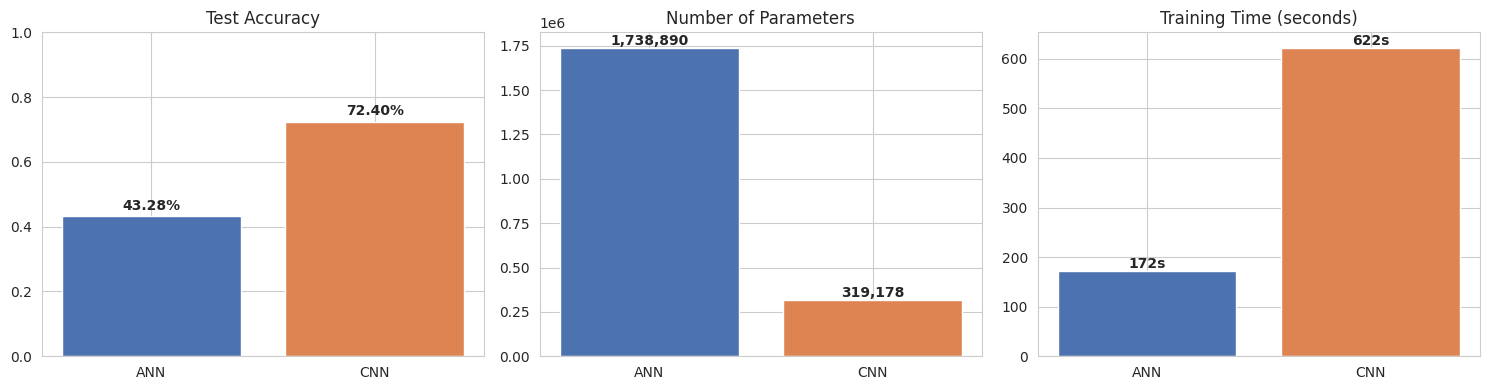

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
colors = ['#4C72B0', '#DD8452']

axes[0].bar(comparison_df['Model'], comparison_df['Test Accuracy'], color=colors)
axes[0].set_title('Test Accuracy')
axes[0].set_ylim(0, 1)
for i, v in enumerate(comparison_df['Test Accuracy']):
    axes[0].text(i, v + 0.02, f"{v:.2%}", ha='center', fontweight='bold')

axes[1].bar(comparison_df['Model'], comparison_df['Parameters'], color=colors)
axes[1].set_title('Number of Parameters')
for i, v in enumerate(comparison_df['Parameters']):
    axes[1].text(i, v, f"{v:,}", ha='center', va='bottom', fontweight='bold')

axes[2].bar(comparison_df['Model'], comparison_df['Training Time (s)'], color=colors)
axes[2].set_title('Training Time (seconds)')
for i, v in enumerate(comparison_df['Training Time (s)']):
    axes[2].text(i, v, f"{v:.0f}s", ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

### 6.2 Training Curves

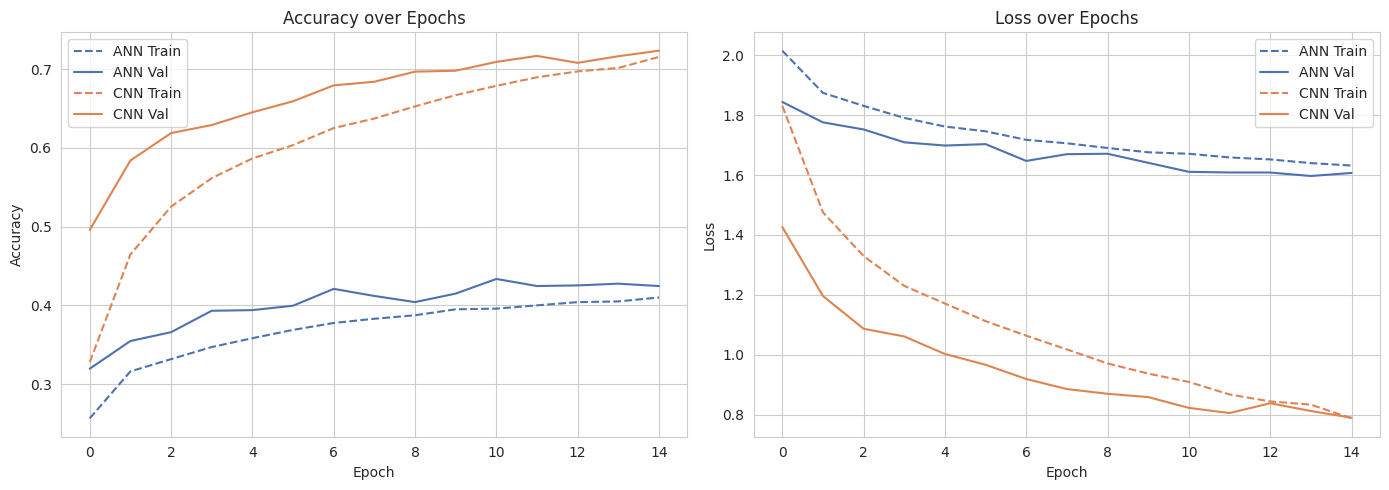

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(ann_history.history['accuracy'], '--', label='ANN Train', color=colors[0])
axes[0].plot(ann_history.history['val_accuracy'], label='ANN Val', color=colors[0])
axes[0].plot(cnn_history.history['accuracy'], '--', label='CNN Train', color=colors[1])
axes[0].plot(cnn_history.history['val_accuracy'], label='CNN Val', color=colors[1])
axes[0].set_title('Accuracy over Epochs')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()

axes[1].plot(ann_history.history['loss'], '--', label='ANN Train', color=colors[0])
axes[1].plot(ann_history.history['val_loss'], label='ANN Val', color=colors[0])
axes[1].plot(cnn_history.history['loss'], '--', label='CNN Train', color=colors[1])
axes[1].plot(cnn_history.history['val_loss'], label='CNN Val', color=colors[1])
axes[1].set_title('Loss over Epochs')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()

plt.tight_layout()
plt.show()

### 6.3 Confusion Matrices

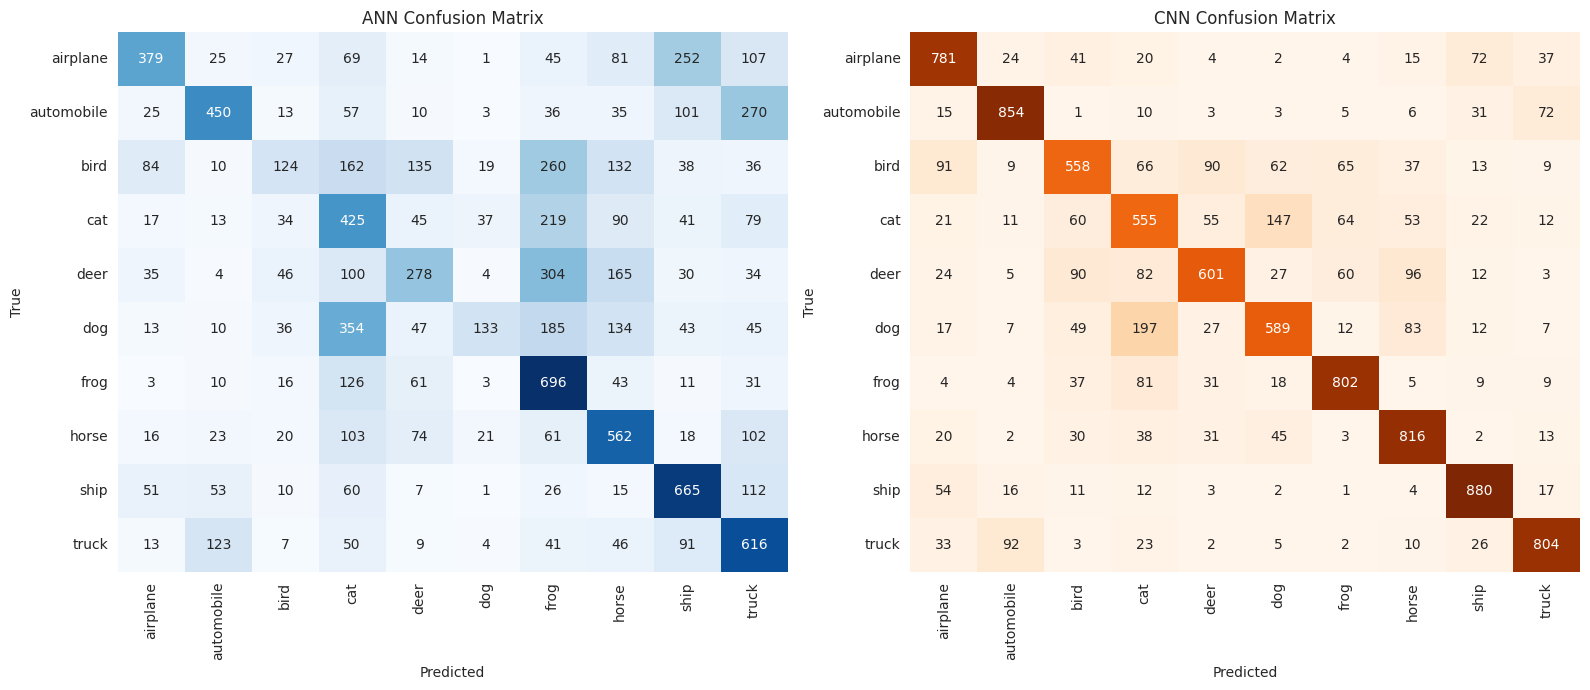

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

ann_cm = confusion_matrix(y_test, ann_preds)
sns.heatmap(ann_cm, annot=True, fmt='d', cmap='Blues', xticklabels=CLASS_NAMES,
            yticklabels=CLASS_NAMES, ax=axes[0], cbar=False)
axes[0].set_title('ANN Confusion Matrix')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('True')

cnn_cm = confusion_matrix(y_test, cnn_preds)
sns.heatmap(cnn_cm, annot=True, fmt='d', cmap='Oranges', xticklabels=CLASS_NAMES,
            yticklabels=CLASS_NAMES, ax=axes[1], cbar=False)
axes[1].set_title('CNN Confusion Matrix')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('True')

plt.tight_layout()
plt.show()

### 6.4 Per-Class Performance (F1-score)

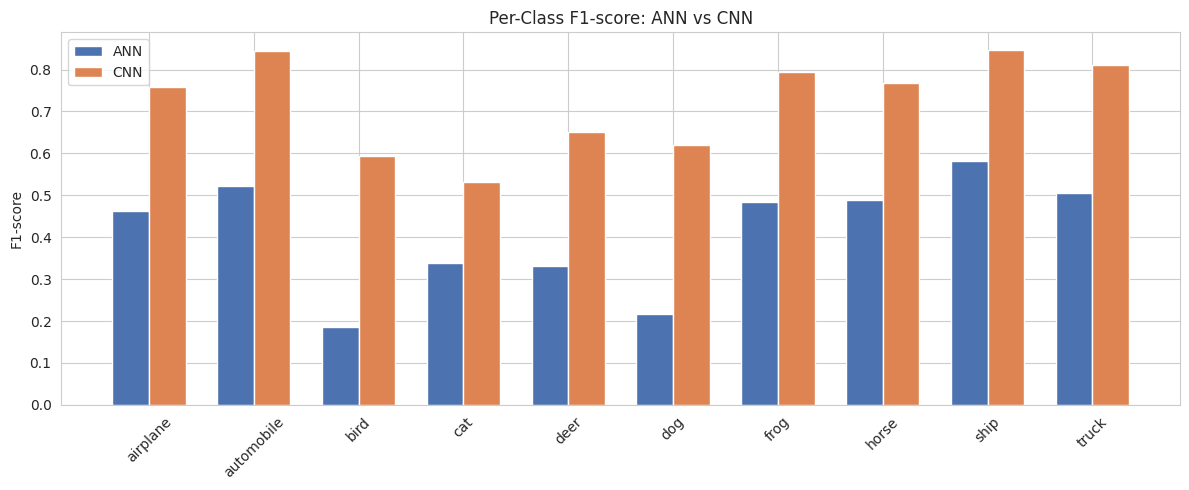

Class,ANN F1,CNN F1
airplane,0.463325,0.758252
automobile,0.522952,0.843874
bird,0.186047,0.593617
cat,0.339186,0.532630
deer,0.330952,0.650785
dog,0.216966,0.620000
frog,0.484511,0.794846
horse,0.488059,0.768000
ship,0.580786,0.846561
truck,0.506579,0.810893


In [15]:
ann_report = classification_report(y_test, ann_preds, target_names=CLASS_NAMES, output_dict=True)
cnn_report = classification_report(y_test, cnn_preds, target_names=CLASS_NAMES, output_dict=True)

f1_df = pd.DataFrame({
    'Class': CLASS_NAMES,
    'ANN F1': [ann_report[c]['f1-score'] for c in CLASS_NAMES],
    'CNN F1': [cnn_report[c]['f1-score'] for c in CLASS_NAMES]
})

x = np.arange(len(CLASS_NAMES))
width = 0.35
fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(x - width/2, f1_df['ANN F1'], width, label='ANN', color=colors[0])
ax.bar(x + width/2, f1_df['CNN F1'], width, label='CNN', color=colors[1])
ax.set_xticks(x)
ax.set_xticklabels(CLASS_NAMES, rotation=45)
ax.set_ylabel('F1-score')
ax.set_title('Per-Class F1-score: ANN vs CNN')
ax.legend()
plt.tight_layout()
plt.show()

f1_df

### 6.5 Sample Predictions (CNN)

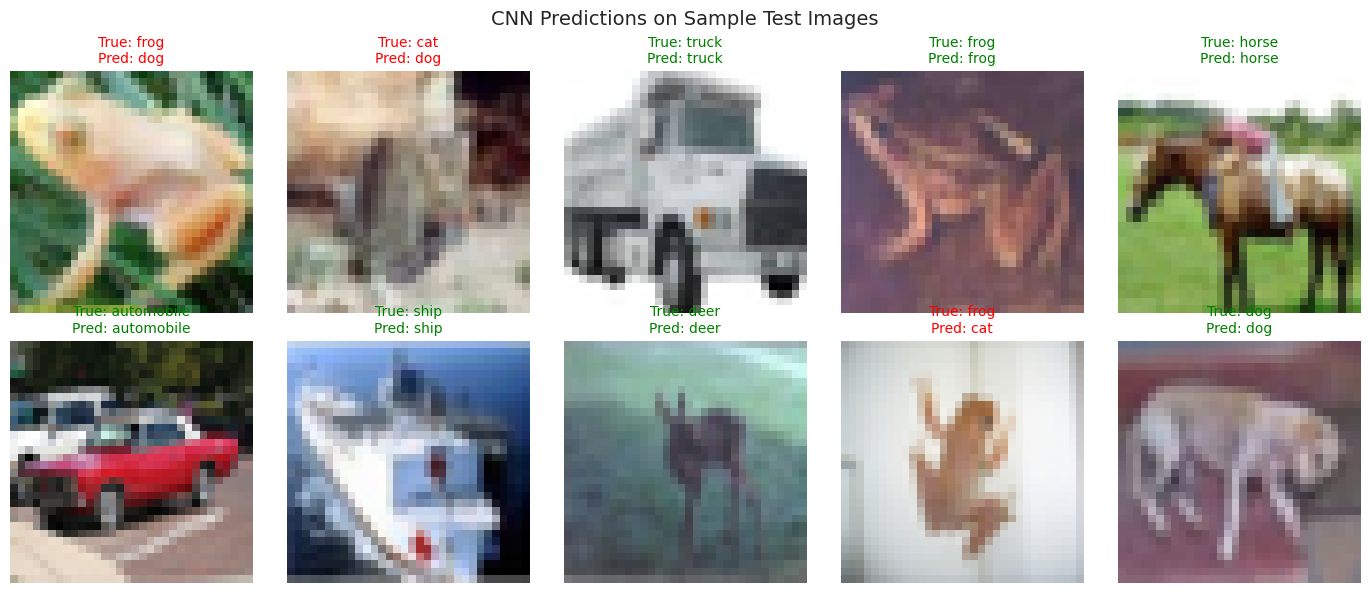

In [16]:
fig, axes = plt.subplots(2, 5, figsize=(14, 6))
rng = np.random.default_rng(7)
sample_idx = rng.choice(len(x_test), 10, replace=False)

for ax, idx in zip(axes.flat, sample_idx):
    ax.imshow(x_test[idx])
    true_label = CLASS_NAMES[y_test[idx]]
    pred_label = CLASS_NAMES[cnn_preds[idx]]
    color = 'green' if true_label == pred_label else 'red'
    ax.set_title(f"True: {true_label}\nPred: {pred_label}", color=color, fontsize=10)
    ax.axis('off')

plt.suptitle('CNN Predictions on Sample Test Images', fontsize=14)
plt.tight_layout()
plt.show()

## 7. Conclusion

In [17]:
print("="*64)
print("FINAL COMPARISON SUMMARY")
print("="*64)
print(f"ANN -> Test Accuracy: {ann_test_acc:.2%} | Parameters: {ann_model.count_params():,} | Time: {ann_train_time:.0f}s")
print(f"CNN -> Test Accuracy: {cnn_test_acc:.2%} | Parameters: {cnn_model.count_params():,} | Time: {cnn_train_time:.0f}s")
print(f"\nCNN improves test accuracy by {(cnn_test_acc-ann_test_acc)*100:.1f} percentage points")
print(f"while using {ann_model.count_params()/cnn_model.count_params():.1f}x FEWER parameters than the ANN.")
print(f"CNN took {cnn_train_time/ann_train_time:.1f}x longer to train ({EPOCHS} epochs each).")

FINAL COMPARISON SUMMARY
ANN -> Test Accuracy: 43.28% | Parameters: 1,738,890 | Time: 171s
CNN -> Test Accuracy: 72.40% | Parameters: 319,178 | Time: 622s

CNN improves test accuracy by 29.1 percentage points
while using 5.4x FEWER parameters than the ANN.
CNN took 3.6x longer to train (15 epochs each).


### Key Takeaways

**The CNN outperforms the ANN despite having far fewer parameters.** That gap comes down to
architecture, not capacity:

1. **Spatial structure is preserved.** The ANN's first step is `Flatten()`, which turns the
   32x32x3 image into a flat vector of 3,072 numbers and permanently discards the fact that
   pixel (i, j) sits next to pixel (i, j+1). The CNN's convolutional filters slide over the
   2-D image directly, so neighboring-pixel relationships — edges, textures, shapes — are
   exactly what the model learns from.
2. **Parameter sharing means efficiency *and* regularization.** A single 3x3 convolutional
   filter is reused at every spatial location, so the network doesn't need a separate weight
   for every pixel position the way a dense layer does. That's why the CNN needs several
   times fewer parameters than the ANN yet still generalizes better — weight sharing acts as
   a built-in regularizer against overfitting.
3. **Hierarchical, translation-tolerant features.** Stacking conv + pooling layers lets the
   network build up from low-level features (edges, color blobs) in early layers to
   higher-level features (object parts) in deeper layers, while pooling adds tolerance to
   small shifts in where an object appears in the frame — a plain dense network has no
   mechanism for either.
4. **The trade-off is compute, not accuracy.** As the training-time chart above shows, the
   CNN takes noticeably longer per epoch than the ANN, because convolution is more
   FLOP-intensive per parameter than a dense matrix multiply. For image tasks, that extra
   training cost is a good trade for the accuracy gained.

**Bottom line:** for image classification problems like CIFAR-10, convolutional
architectures are the appropriate default. A fully-connected network can technically be
pointed at image data, but it throws away the one piece of information — spatial locality —
that makes images tractable to learn from in the first place.

### Possible Further Improvements
- Data augmentation (random flips/crops/rotations) to reduce overfitting and improve CNN
  generalization.
- A deeper CNN with batch normalization, or a well-known architecture (ResNet, VGG-style
  blocks) for higher accuracy.
- Learning-rate scheduling / `ReduceLROnPlateau` for more stable convergence.
- Transfer learning from a model pretrained on ImageNet (e.g., via `tf.keras.applications`).